## Google Colab Setup

This tutorial is designed to run in [Google Colab](https://colab.research.google.com/). Before running the notebook, complete the following steps:

- Go to **Runtime -> Change runtime type** and select **T4 GPU**  
- Install [TerraTorch](https://github.com/terrastackai/terratorch), a machine learning library for working with geospatial data  
  - After running the `pip install` cell, you will be prompted to restart the session  
  - After restarting, re-run the `pip install` command in the new session

In [1]:
# %pip install terratorch==1.1.1

## The Hail and Wind Damage Swath (HWDS) Event Database

For labels, we are going to be using a 21-year climatology (2000-2020) of hail and wind damage swaths derived from daily MODIS imagery and storm reports. A subset of the HWDS database (~60 swaths) will be used for training that overlaps with the period of record of both HLS and Sentinel-1 data.

Hail and wind damage swaths (HWDSs) frequently occur during the warmest months of the growing season throughout the Midwest and Great Plains but are not yet officially documented or tracked like other severe weather impacts (e.g., tornadoes and derechos). This dataset was created from a 21-year HWDS event database using archived daily storm reports and daily true color satellite imagery. Once the database was completed and underwent quality checks, the research team identified spatial and temporal trends from the confirmed swaths.

For more information check out the [github repo](https://github.com/jrbell1/hwds_db).

# Download Data From Hugging Face

A Hugging Face repository containing with pre-chipped data is available at:  

- https://huggingface.co/datasets/wbhorn/hail_and_wind_damage_chips

More tutorials are available at:  

- https://github.com/ASFHyP3/geospatial-ai-tutorials

In [2]:
# !wget https://huggingface.co/datasets/wbhorn/hail_and_wind_damage_chips/resolve/main/hwds_multimodal.zip
# !unzip -q hwds_multimodal.zip

In [3]:
import warnings
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import torch
import lightning.pytorch as pl
import albumentations
import terratorch
from sklearn.model_selection import train_test_split
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
import rasterio
from rasterio.merge import merge


warnings.filterwarnings("ignore")

Setup some directories and load pre-compted dataset means and stds

In [4]:
DATA_PATH = Path('hwds_pristine')
HLS_CHIP_PATH = DATA_PATH / 'HLS'
LABEL_CHIP_PATH = DATA_PATH / 'LABEL'
STATS_PATH = DATA_PATH / 'statistics.json'

SPLIT_PATH = DATA_PATH / 'SPLITS'
SPLIT_PATH.mkdir(exist_ok=True, parents=True)

stats = json.loads(STATS_PATH.read_text(encoding="utf-8"))['HLS']
print(json.dumps(stats,indent=2))

{
  "means": {
    "B": 295.2791748046875,
    "G": 558.80859375,
    "R": 419.784912109375,
    "N": 3881.2568359375,
    "SW1": 1956.6075439453125,
    "SW2": 1002.3595581054688
  },
  "stds": {
    "B": 138.65139770507812,
    "G": 195.55235290527344,
    "R": 280.36407470703125,
    "N": 642.6063842773438,
    "SW1": 576.72998046875,
    "SW2": 494.6283264160156
  }
}


In [5]:
chip_means = list(stats['means'].values())
chip_stds = list(stats['stds'].values())

chip_means, chip_stds

([295.2791748046875,
  558.80859375,
  419.784912109375,
  3881.2568359375,
  1956.6075439453125,
  1002.3595581054688],
 [138.65139770507812,
  195.55235290527344,
  280.36407470703125,
  642.6063842773438,
  576.72998046875,
  494.6283264160156])

We are splitting up our chips based on individual damage events

In [6]:
image_grep = '*.*.*.*.stacked.tif'
label_grep = '*.*.*.MASK.tif'

In [7]:
band_paths = list(LABEL_CHIP_PATH.glob(label_grep))

swaths = set(band_path.name.split('.')[2] for band_path in band_paths) 
swaths

{'102a',
 '1052a',
 '1055a',
 '1056a',
 '1064a',
 '1069a',
 '106a',
 '1079a',
 '110d',
 '116d',
 '116e',
 '126a',
 '127a',
 '129a',
 '130a',
 '132a',
 '1338a',
 '133a',
 '1347a',
 '134a',
 '1373a',
 '1373d',
 '1373e',
 '1376a',
 '1378a',
 '598a',
 '614a',
 '623a',
 '623d',
 '628a',
 '638a',
 '648a',
 '889a',
 '889b',
 '892a',
 '915a'}

In [9]:
the_rest, test = train_test_split(list(swaths), test_size=0.1)
train, val = train_test_split(the_rest, test_size=0.15)

print('Training Events:', len(train))
print('Validation Events:', len(val))
print('Testing Events:', len(test))

splits = {"train": train, "val": val, "test": test}

for split, swath_ids in splits.items():
    split_path = SPLIT_PATH / f"{split}.txt"
    split_path.write_text("\n".join(swath_ids))


Training Events: 27
Validation Events: 5
Testing Events: 4


In [10]:
def plot_sample(sample):
    data = sample['image'].cpu().numpy()
    mask = sample['mask'].cpu().numpy()

    # Scaling data.
    if data.mean() < 1:
        data = data * 10000
    data = (data.clip(0, 2000) / 2000) * 255
    rgb = data[[2, 1, 0]].astype(np.uint8).transpose(1,2,0)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(rgb)
    ax[0].set_title('Image')
    ax[0].axis('off')
    ax[1].imshow(mask, vmin=-1, vmax=1, interpolation='nearest')
    ax[1].set_title('Mask')
    ax[1].axis('off')
    ax[2].imshow(rgb)
    ax[2].imshow(mask, vmin=-1, vmax=1, interpolation='nearest', alpha=0.5)
    ax[2].set_title('Mask on Image')
    ax[2].axis('off')
    fig.tight_layout()
    plt.show()

Setup datamodule to load the data. Based off of terramind burnscare tutorial:

- https://github.com/IBM/terramind/blob/main/notebooks%2Fterramind_v1_small_burnscars.ipynb

In [11]:
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=16,
    num_workers=8,
    num_classes=2,
    rgb_indices=[2, 1, 0],

    train_data_root=str(HLS_CHIP_PATH),
    train_label_data_root=str(LABEL_CHIP_PATH),
    val_data_root=str(HLS_CHIP_PATH),
    val_label_data_root=str(LABEL_CHIP_PATH),
    test_data_root=str(HLS_CHIP_PATH),
    test_label_data_root=str(LABEL_CHIP_PATH),

    train_split=str(SPLIT_PATH / "train.txt"),
    val_split=str(SPLIT_PATH / "val.txt"),
    test_split=str(SPLIT_PATH / "test.txt"),

    img_grep=image_grep,
    label_grep=label_grep,
    #  You can define a constant_scale that applies a multiplicator in case the data does not align with the the standardization values.
    # constant_scale=None,
    means=chip_means,
    stds=chip_stds,
    # fyi TerraMind pretraining values (assuming data in range 0-10000)
    # S2L2A means: [1390.458, 1503.317, 1718.197, 1853.910, 2199.100, 2779.975, 2987.011, 3083.234, 3132.220, 3162.988, 2424.884, 1857.648]
    # S2L2A stds: [2106.761, 2141.107, 2038.973, 2134.138, 2085.321, 1889.926, 1820.257, 1871.918, 1753.829, 1797.379, 1434.261, 1334.311]

    # albumentations supports shared transformations and can handle multimodal inputs.
    train_transform=[
        # albumentations.D4(),  # Random flips and rotation
        albumentations.pytorch.transforms.ToTensorV2(),
    ],
    val_transform=None,  # Fallback to ToTensor
    test_transform=None,
    no_label_replace=-1,  # Replace NaN labels. defaults to -1 which is ignored in the loss and metrics.
    no_data_replace=0,  # Replace NaN data
)

Plot some chips

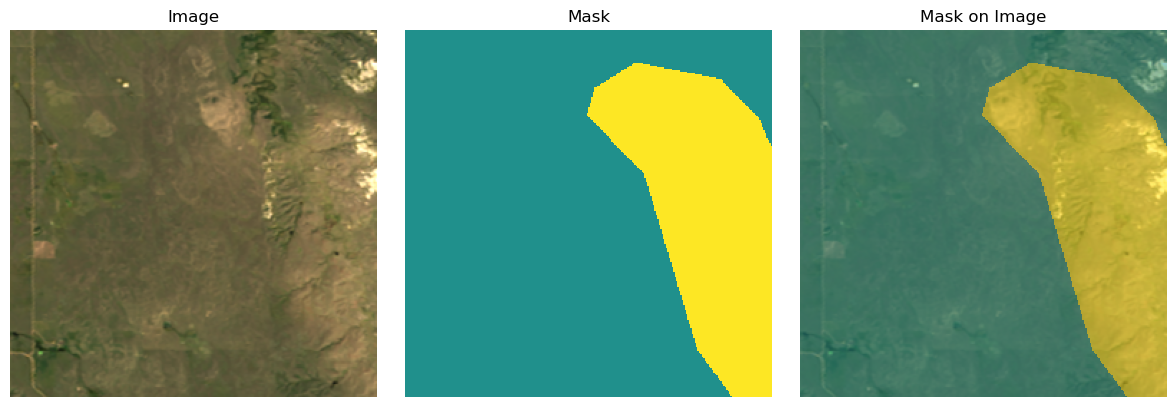

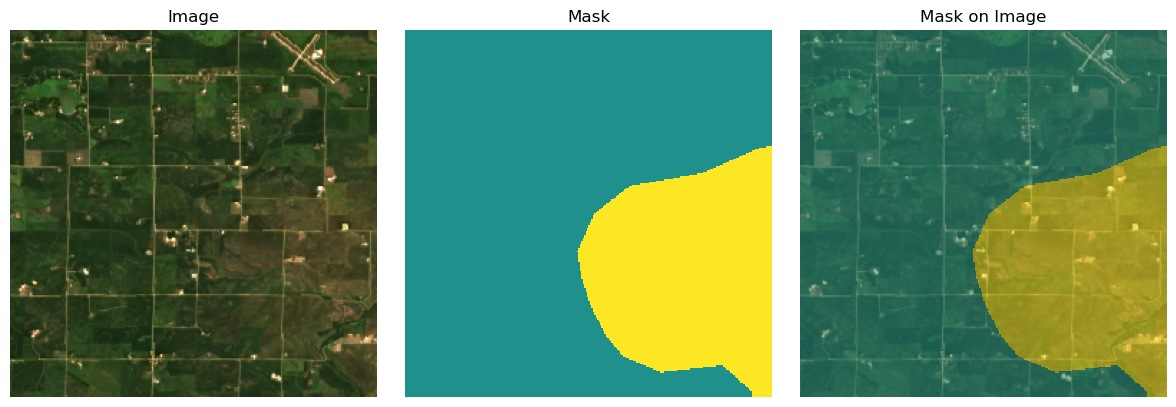

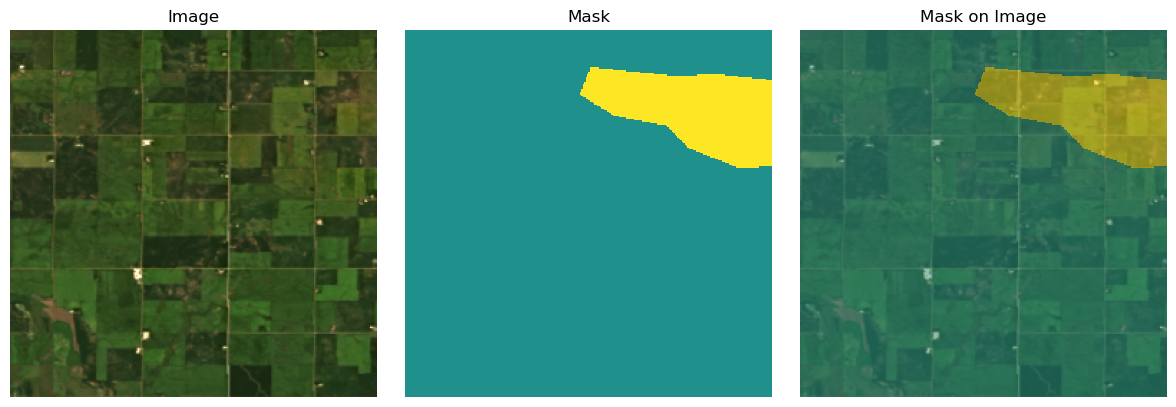

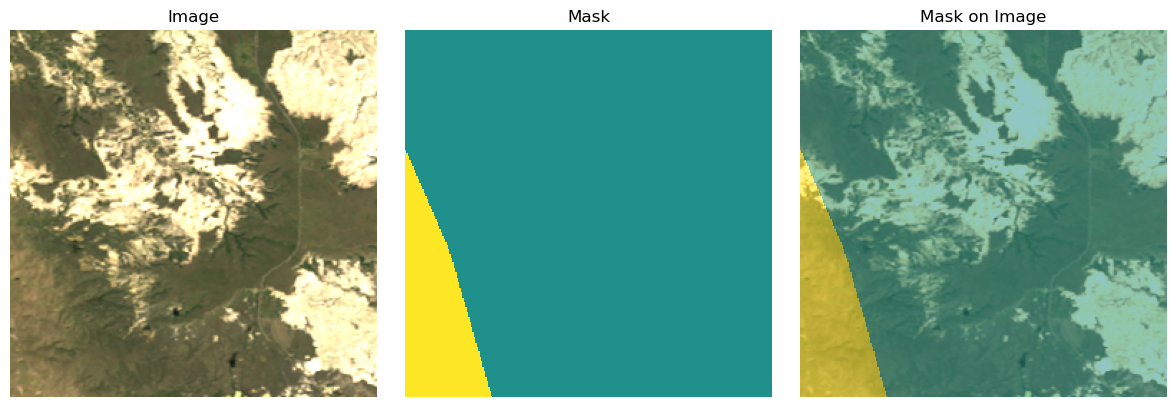

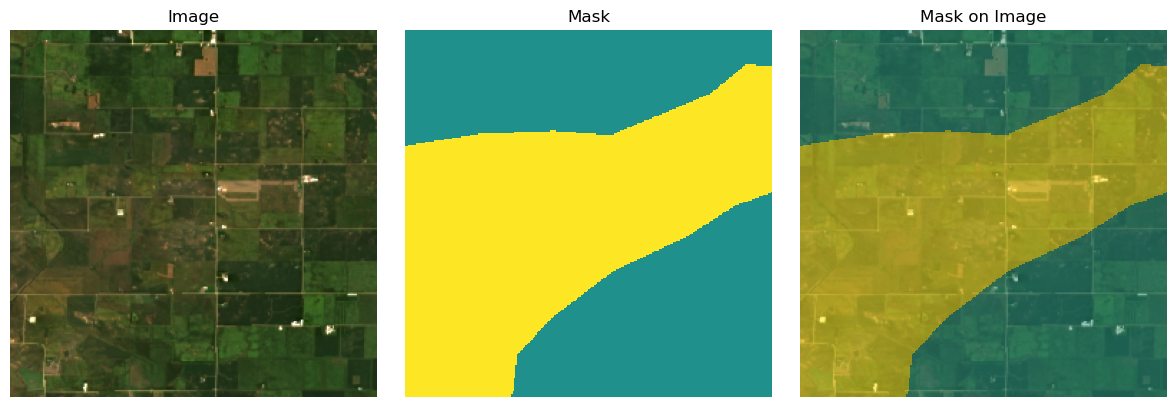

In [12]:
datamodule.setup("fit")

val_dataset = datamodule.val_dataset
len(val_dataset)

for i in range(5):
    plot_sample(val_dataset[i])

Setup the trainer and the model (also based on burnscares tutorial)

In [31]:
# By default, TerraTorch saves the model with the best validation loss. You can overwrite this by defining a custom ModelCheckpoint, e.g., saving the model with the highest validation mIoU.
# TODO Optionally adjust the checkpoint
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath='output/terramind_hwds_base',
    mode="max",
    monitor="val/mIoU", # Variable to monitor
    filename="best-mIoU",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices=1, # Deactivate multi-gpu because it often fails in notebooks
    precision="16-mixed",  # Speed up training with half precision, delete for full precision training.
    num_nodes=1,
    logger=True,  # Uses TensorBoard by default
    max_epochs=100, # For demos
    log_every_n_steps=1,
    callbacks=[checkpoint_callback],
    # TODO Define output dir
    default_root_dir='output/terramind_hwds_base',
)

# Segmentation mask that build the model and handles training and validation steps.
model = terratorch.tasks.SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",  # Combines a backbone with necks, the decoder, and a head
    model_args={
        # TerraMind backbone
        "backbone": "terramind_v1_base",
        "backbone_pretrained": True,
        # Select the modality. Check the docs for details https://terrastackai.github.io/terratorch/stable/guide/terramind/#subset-of-input-bands
        "backbone_modalities": ["S2L2A"],
        # Define the input bands. This is only needed because you need to select a subset of the pre-training bands
        #  Check the names in the "List of pre-trained bands" in the docs.
        "backbone_bands": {"S2L2A": ["BLUE","GREEN","RED","NIR_NARROW","SWIR_1","SWIR_2"]},

        # Necks
        "necks": [
            {
                "name": "SelectIndices",
                "indices": [2, 5, 8, 11] # indices for terramind_v1_base
                # "indices": [5, 11, 17, 23] # indices for terramind_v1_large
            },
            {"name": "ReshapeTokensToImage",
                "remove_cls_token": False},  # TerraMind is trained without CLS token, which neads to be specified.
            {"name": "LearnedInterpolateToPyramidal"}  # Some decoders like UNet or UperNet expect hierarchical features. Therefore, we need to learn a upsampling for the intermediate embedding layers when using a ViT like TerraMind.
        ],

        # Decoder
        "decoder": "UNetDecoder",
        #"decoder_channels": [256, 128, 64, 32],
        "decoder_channels" : [256, 128, 64, 32],

        # Head
        "head_dropout": 0.1,
        "num_classes": 2,
    },

    loss="dice",  # We recommend dice for binary tasks and ce for tasks with multiple classes.
    optimizer="AdamW",
    lr=2e-5,  # The optimal learning rate varies between datasets, we recommend testing different once between 1e-5 and 1e-4. You can perform hyperparameter optimization using terratorch-iterate.  
    scheduler='ReduceLROnPlateau',  # optionally define a learning rate scheduler and pass hparams
    scheduler_hparams={
        'factor': 0.5,  # This "reduce LR on plateau" scheduler multiplies the lr by <factor> when the val loss did not improve for <patience> epochs
        'patience': 5
    },
    ignore_index=-1,
    freeze_backbone=False, # Only used to speed up fine-tuning in this demo, we highly recommend fine-tuning the backbone for the best performance.
    freeze_decoder=False,  # Should be false in most cases as the decoder is randomly initialized.
    plot_on_val=True,  # Plot predictions during validation steps
    class_names=["Others", "Damage"],  # optionally define class names
    class_weights=[0.5, 0.5]
)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
INFO:root:Loaded weights for BLUE in position 0 of patch embed
INFO:root:Loaded weights for GREEN in position 1 of patch embed
INFO:root:Loaded weights for RED in position 2 of patch embed
INFO:root:Loaded weights for NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for SWIR_2 in position 5 of patch embed


Just load all the datasets

In [32]:
datamodule.setup("train")
datamodule.setup("test")
print(len(datamodule.train_dataset), len(datamodule.val_dataset), len(datamodule.test_dataset))

359 32 35


In [33]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Sometimes I have to run this cell multiple times for tensorboard to show up

In [34]:
%tensorboard --logdir output

Reusing TensorBoard on port 6006 (pid 115289), started 0:18:22 ago. (Use '!kill 115289' to kill it.)

Perform fine tuning on the model. You can refresh the tensorboard to track progress.

In [35]:
# Training
trainer.fit(model, datamodule=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | PixelWiseModel   | 94.1 M | train
1 | criterion     | DiceLoss         | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | ModuleList       | 0      | train
-----------------------------------------------------------
94.1 M    Trainable params
0         Non-trainable params
94.1 M    Total params
376.218   Total estimated model params size (MB)
288       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

INFO:terratorch:Checking stackability for val split.


INFO:terratorch:Checking stackability for train split.


Epoch 99: 100%|██████████| 22/22 [00:04<00:00,  4.82it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 22/22 [00:04<00:00,  4.81it/s, v_num=1]


# Testing

Restoring states from the checkpoint path at output/terramind_hwds_base/best-mIoU.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at output/terramind_hwds_base/best-mIoU.ckpt
INFO:terratorch:Checking stackability for test split.


Testing DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 32.36it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric         ┃        DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy        │     0.8033279776573181     │
│     test/Boundary_mIoU     │    0.032069332897663116    │
│ test/Class_Accuracy_Damage │     0.7093287110328674     │
│ test/Class_Accuracy_Others │     0.8973272442817688     │
│       test/F1_Score        │     0.8099305629730225     │
│      test/IoU_Damage       │     0.5906153321266174     │
│      test/IoU_Others       │     0.7813185453414917     │
│    test/Pixel_Accuracy     │     0.8337641954421997     │
│         test/loss          │    0.31369924545288086     │
│         test/mIoU          │     0.685966968536377      │
│      test/mIoU_Micro       │     0.7149190902709961     │
└────────────────────────────┴────────────────────────────┘

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
INFO:root:Loaded weights for BLUE in position 0 of patch embed
INFO:root:Loaded weights for GREEN in position 1 of patch embed
INFO:root:Loaded weights for RED in position 2 of patch embed
INFO:root:Loaded weights for NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for SWIR_2 in position 5 of patch embed
INFO:terratorch:Checking stackability for test split.


test_dataset: 35


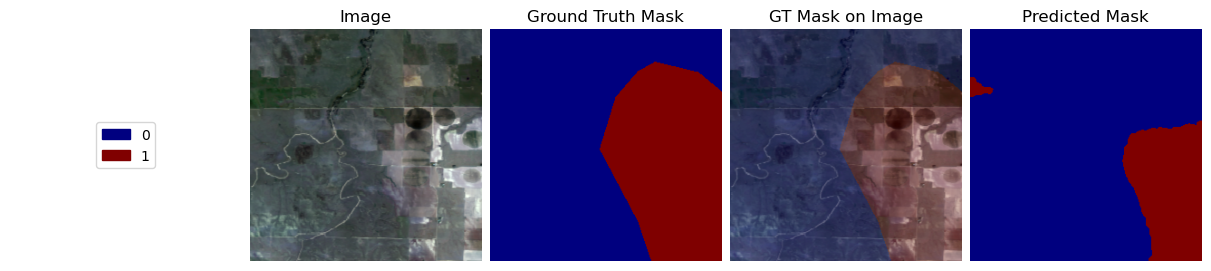

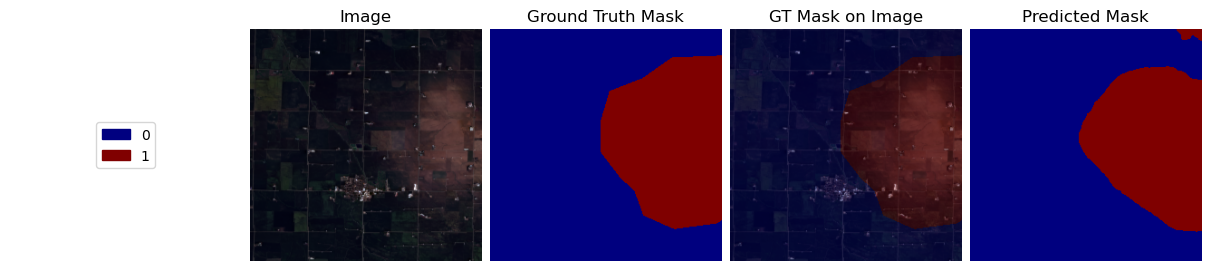

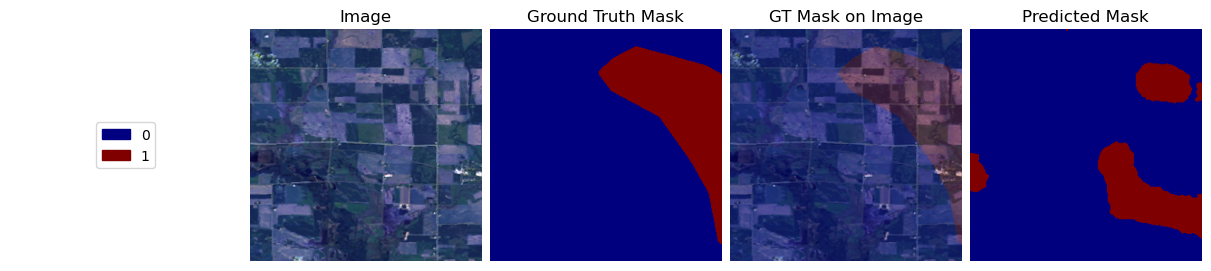

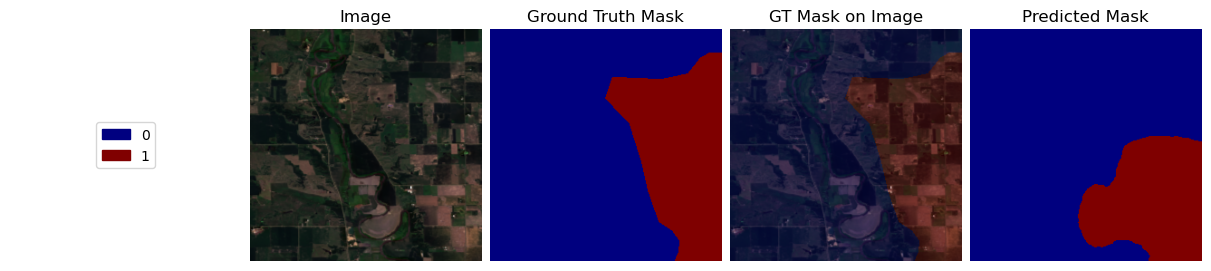

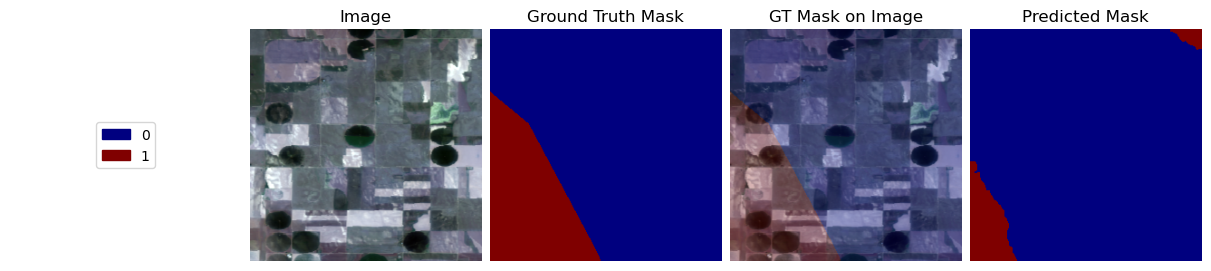

In [36]:
# Let's test the fine-tuned model
best_ckpt_path = "output/terramind_hwds_base/best-mIoU.ckpt"
trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt_path)

# Now we can use the model for predictions and plotting
# from https://github.com/IBM/terramind/blob/main/notebooks%2Fterramind_v1_small_multitemporal_crop.ipynb
# rest of examples in notebook from
# https://github.com/IBM/terramind/blob/main/notebooks%2Fterramind_v1_small_burnscars.ipynb
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
    batch_size=1
)
model.eval()

datamodule.setup("test")
test_dataset = datamodule.test_dataset
test_loader = datamodule.test_dataloader()
print('test_dataset:',len(test_dataset))

with torch.no_grad():
    batch = next(iter(test_loader))
    batch = datamodule.aug(batch)
 
    images = batch["image"]
    images = images.to(model.device)
    masks = batch["mask"].numpy()

    with torch.no_grad():
        outputs = model(images)

    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(5):
    sample = {
        "image": batch["image"][i].cpu(),
        "mask": batch["mask"][i],
        "prediction": preds[i],
    }
    test_dataset.plot(sample)
    plt.show()

View predicted event mosaic

In [37]:
train_events = (SPLIT_PATH / 'train.txt').read_text().split('\n')
val_events = (SPLIT_PATH / 'val.txt').read_text().split('\n')
test_events = (SPLIT_PATH / 'test.txt').read_text().split('\n')

In [38]:
best_ckpt_path = "output/terramind_hwds_base/best-mIoU.ckpt"
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
    batch_size=1
)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
INFO:root:Loaded weights for BLUE in position 0 of patch embed
INFO:root:Loaded weights for GREEN in position 1 of patch embed
INFO:root:Loaded weights for RED in position 2 of patch embed
INFO:root:Loaded weights for NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for SWIR_2 in position 5 of patch embed


In [39]:
event = train_events[0]
event_band_chips = list(HLS_CHIP_PATH.glob(f'*.{event}.*.tif'))

chips = []
for band in event_band_chips:
    chip_id = '.'.join(band.name.split('.')[:3])
    mask = LABEL_CHIP_PATH / f'{chip_id}.MASK.tif'  
    break

print(chip_id, mask)


002.002.889b hwds_pristine/LABEL/002.002.889b.MASK.tif


In [40]:
def chips_for_event(event):
    event_band_chips = list(HLS_CHIP_PATH.glob(f'*.{event}.*.tif'))

    chips = []
    for band in event_band_chips:
        chip_id = '.'.join(band.name.split('.')[:3])
        mask = LABEL_CHIP_PATH / f'{chip_id}.MASK.tif'  

        chips.append({
            'label': mask,
            'image': band,
            'swath': event
        })

    return chips

def generate_predictions(chip, output_path):
    with rasterio.open(chip['image']) as ds:
        image_data = ds.read()
    with rasterio.open(chip['label']) as ds:
        profile = ds.profile 

    with torch.no_grad():
        image = torch.from_numpy(image_data).float()
        # normalize
        image = (image - torch.tensor(chip_means).view(-1,1,1)) / torch.tensor(chip_stds).view(-1,1,1)
        image = image.unsqueeze(0).to(model.device)

        with torch.no_grad():
            outputs = model(image)

        preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

    pred_name = chip['image'].name.replace('BANDS.tif', 'PRED.tif')
    pred_path = output_path / pred_name
    profile.update(
        count=1,
    )
    profile.pop('blockxsize', None)
    profile.pop('blockysize', None)
    profile.pop('tiled', None)

    with rasterio.open(pred_path, "w", **profile) as dst:
        dst.write(preds[0], 1)

    chip['prediction'] = pred_path

    return chip

def merge_chips(chips, output_file):
    band_datasets = [rasterio.open(chip) for chip in chips]

    try:
        mosaic, out_trans = merge(band_datasets)

        out_meta = band_datasets[0].meta.copy()

        out_meta.update(
            {
                "driver": "GTiff",
                "height": mosaic.shape[1],
                "width": mosaic.shape[2],
                "transform": out_trans,
                "crs": band_datasets[0].crs,
                "count": mosaic.shape[0],
            }
        )

        with rasterio.open(output_file, "w", **out_meta) as dst:
            dst.write(mosaic)

    finally:
        for ds in band_datasets:
            ds.close()

    return output_file

In [41]:
def plot_merged(merged):
    # 'label', 'prediction', 'image' 
    with rasterio.open(merged['image']) as ds:
        data = ds.read()
        data[data == -9999] = np.nan
    with rasterio.open(merged['label']) as ds:
        mask = ds.read().squeeze()
    with rasterio.open(merged['prediction']) as ds:
        prediction = ds.read().squeeze()

    # Scaling data.
    if data.mean() < 1:
        data = data * 10000
    data = (data.clip(0, 2000) / 2000) * 255
    rgb = data[[2, 1, 0]].astype(np.uint8).transpose(1,2,0)

    fig, ax = plt.subplots(2, 3, figsize=(10, 5))

    ax[0][0].imshow(rgb)
    ax[0][0].set_title('Image')
    ax[0][0].axis('off')
    ax[0][1].imshow(mask, vmin=-1, vmax=1, interpolation='nearest')
    ax[0][1].set_title('Mask')
    ax[0][1].axis('off')
    ax[0][2].imshow(rgb)
    ax[0][2].imshow(mask, vmin=-1, vmax=1, interpolation='nearest', alpha=0.3)
    ax[0][2].set_title('Mask on Image')
    ax[0][2].axis('off')

    ax[1][0].imshow(rgb)
    ax[1][0].set_title('Image')
    ax[1][0].axis('off')
    ax[1][1].imshow(prediction, vmin=-1, vmax=1, interpolation='nearest')
    ax[1][1].set_title('Prediction')
    ax[1][1].axis('off')
    ax[1][2].imshow(rgb)
    ax[1][2].imshow(prediction, vmin=-1, vmax=1, interpolation='nearest', alpha=0.3)
    ax[1][2].set_title('Prediction on Image')
    ax[1][2].axis('off')
    fig.tight_layout()
    plt.show()


generating chips
merging chips


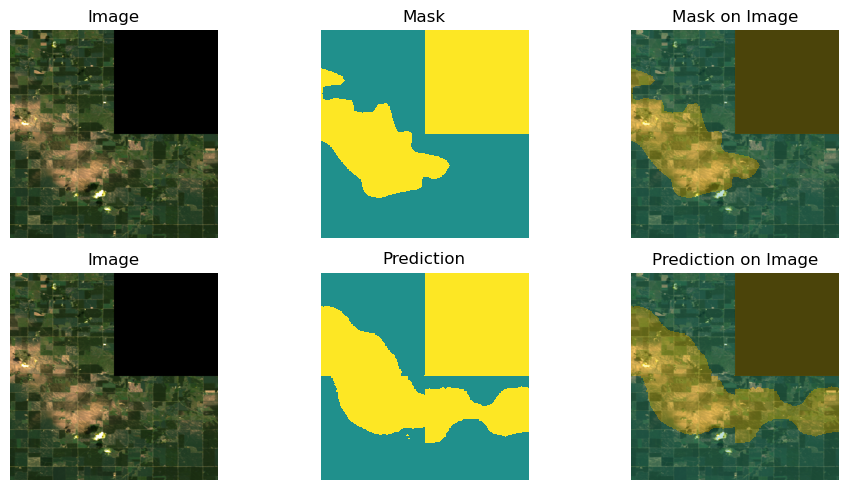

generating chips
merging chips


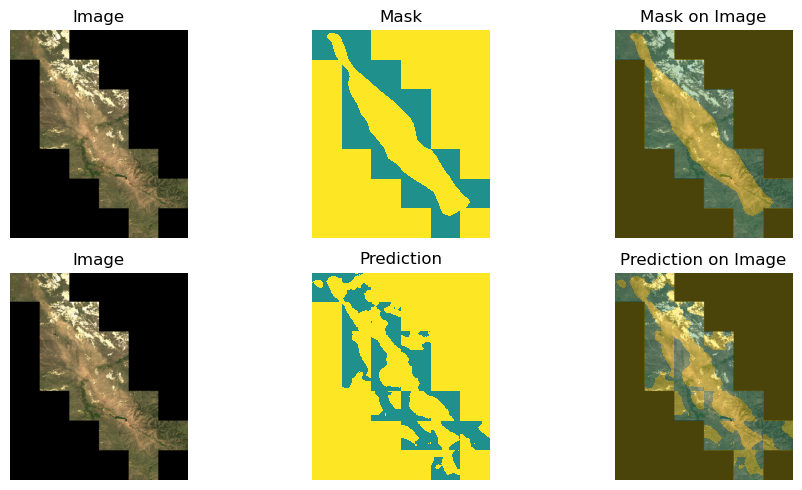

generating chips
merging chips


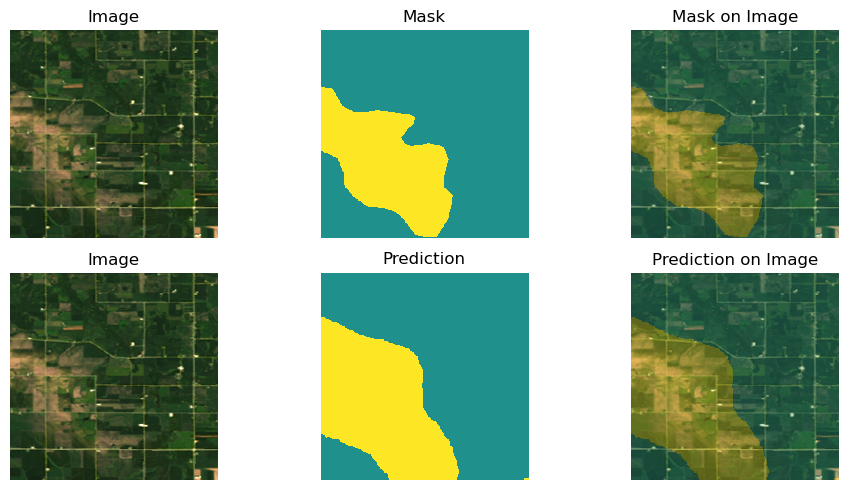

generating chips
merging chips


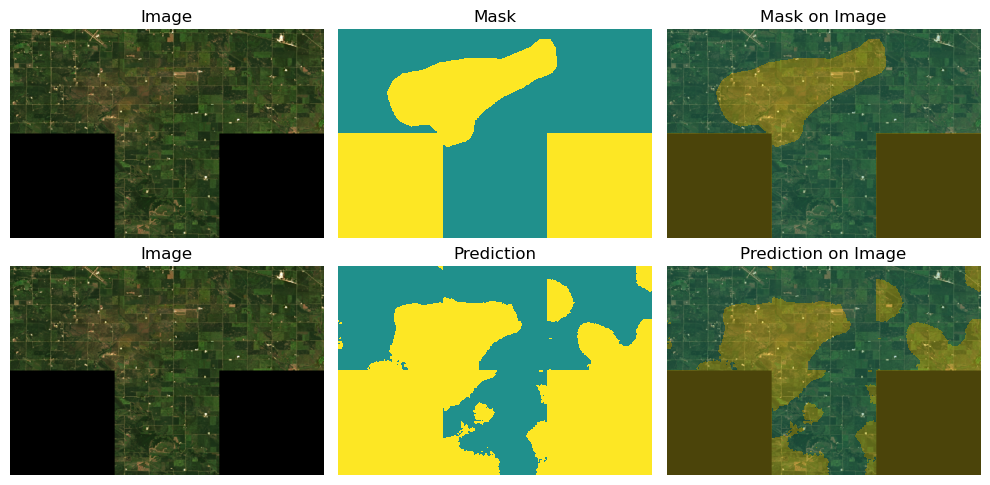

generating chips
merging chips


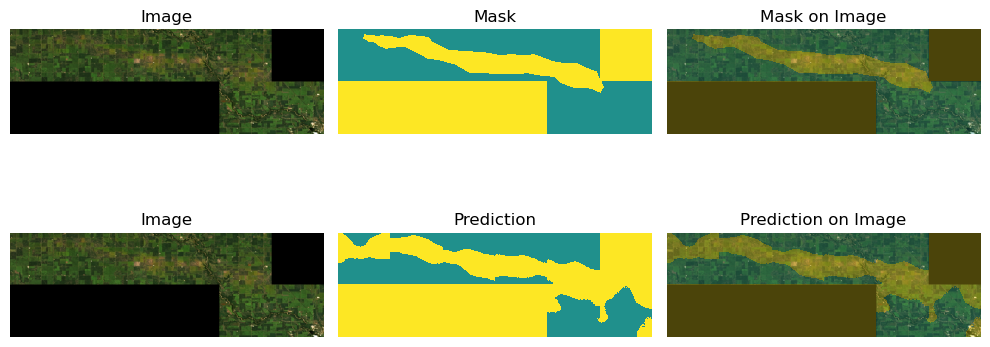

generating chips
merging chips


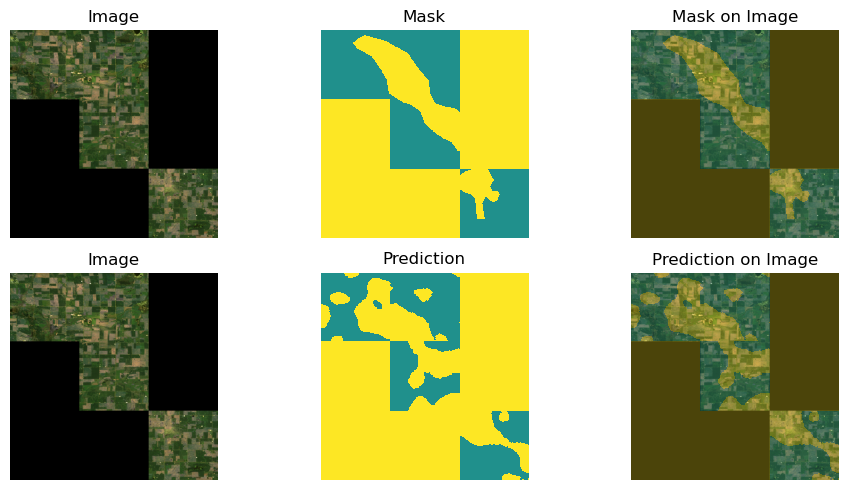

generating chips
merging chips


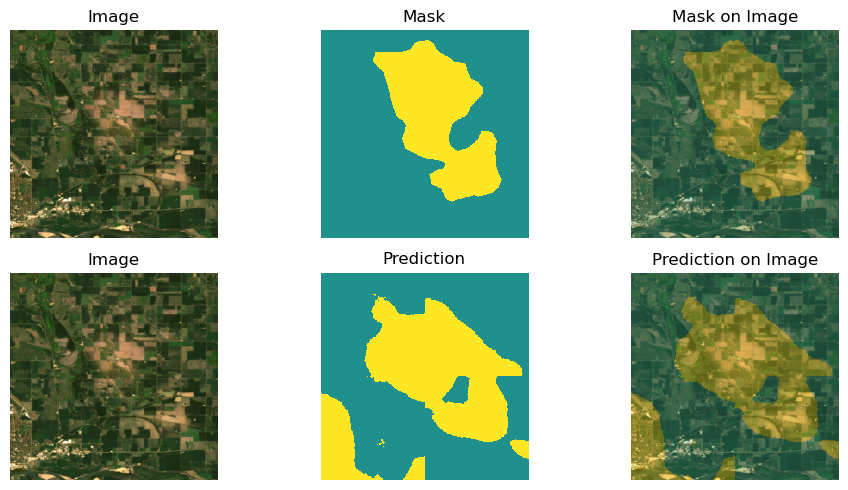

generating chips
merging chips


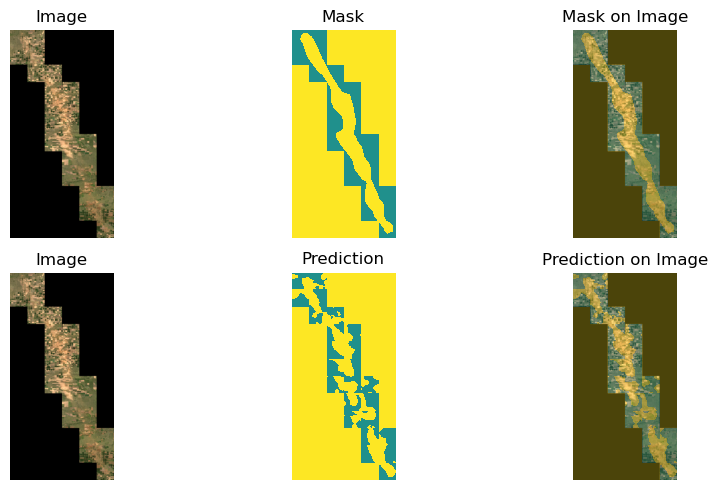

generating chips
merging chips


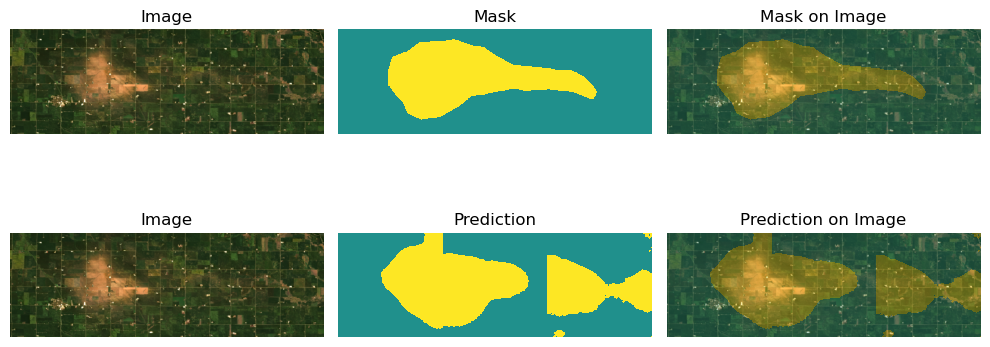

In [43]:
events = train_events

for event in (*val_events, *test_events):
    event_chips = chips_for_event(event)
    pred_path = Path('preds') / 'hls'
    merge_path = pred_path / 'merged' 
    merge_path.mkdir(exist_ok=True, parents=True)
    
    if not len(event_chips):
        print(f'Can not find and chips for event {event}')
        continue

    swath = event_chips[0]['swath']

    chips_with_preds = []
    print('generating chips')
    for event_chip in event_chips:
        event_pred_path = pred_path / event_chip['swath']
        event_pred_path.mkdir(exist_ok=True, parents=True)

        chip = generate_predictions(event_chip, event_pred_path)
        chips_with_preds.append(chip)

    print('merging chips')
    merged = {} 
    for chip_type in ('label', 'prediction', 'image' ):
        paths = [chip[chip_type] for chip in chips_with_preds]
        merged_path = merge_chips(paths, pred_path / 'merged' / f'{swath}.{chip_type}.tif')
        merged[chip_type] = merged_path

    plot_merged(merged)